# 2주차: Decision Tree

와인 데이터를 이용해서 Decision Tree 모델 실습

## 라이브러리

In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## 데이터 로드

In [ ]:
red_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/winequality-red.csv'
white_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/winequality-white.csv'

red_wine = pd.read_csv(red_url, sep=';')
white_wine = pd.read_csv(white_url, sep=';')

In [ ]:
red_wine['color'] = 1.
white_wine['color'] = 0.

data = pd.concat([red_wine, white_wine])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 710.6 KB


In [ ]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0.0
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0.0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0.0
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0.0


### 와인 데이터셋 컬럼 설명

*   `fixed acidity`: 고정 산도 (와인의 신맛에 영향)
*   `volatile acidity`: 휘발성 산도 (높으면 식초와 같은 신맛이 강해짐)
*   `citric acid`: 시트르산 함량 (신선한 신맛을 더함)
*   `residual sugar`: 잔류 당분 (와인의 단맛을 결정)
*   `chlorides`: 염화물 함량 (와인의 짠맛에 영향)
*   `free sulfur dioxide`: 자유 이산화황 (산화 및 미생물 번식 방지)
*   `total sulfur dioxide`: 총 이산화황 (첨가된 총 이산화황의 양)
*   `density`: 밀도 (당분과 알코올 함량에 영향)
*   `pH`: pH (와인의 산성도, 낮을수록 산성)
*   `sulphates`: 황산염 함량 (쓴맛과 항산화 작용)
*   `alcohol`: 알코올 함량 (와인의 도수)
*   `quality`: 품질 점수 (높을수록 좋은 품질)
*   `color`: 와인의 색깔 (레드 와인/화이트 와인 구분)

In [ ]:
# describe() 메서드 사용
description = data.describe()
print(description)

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

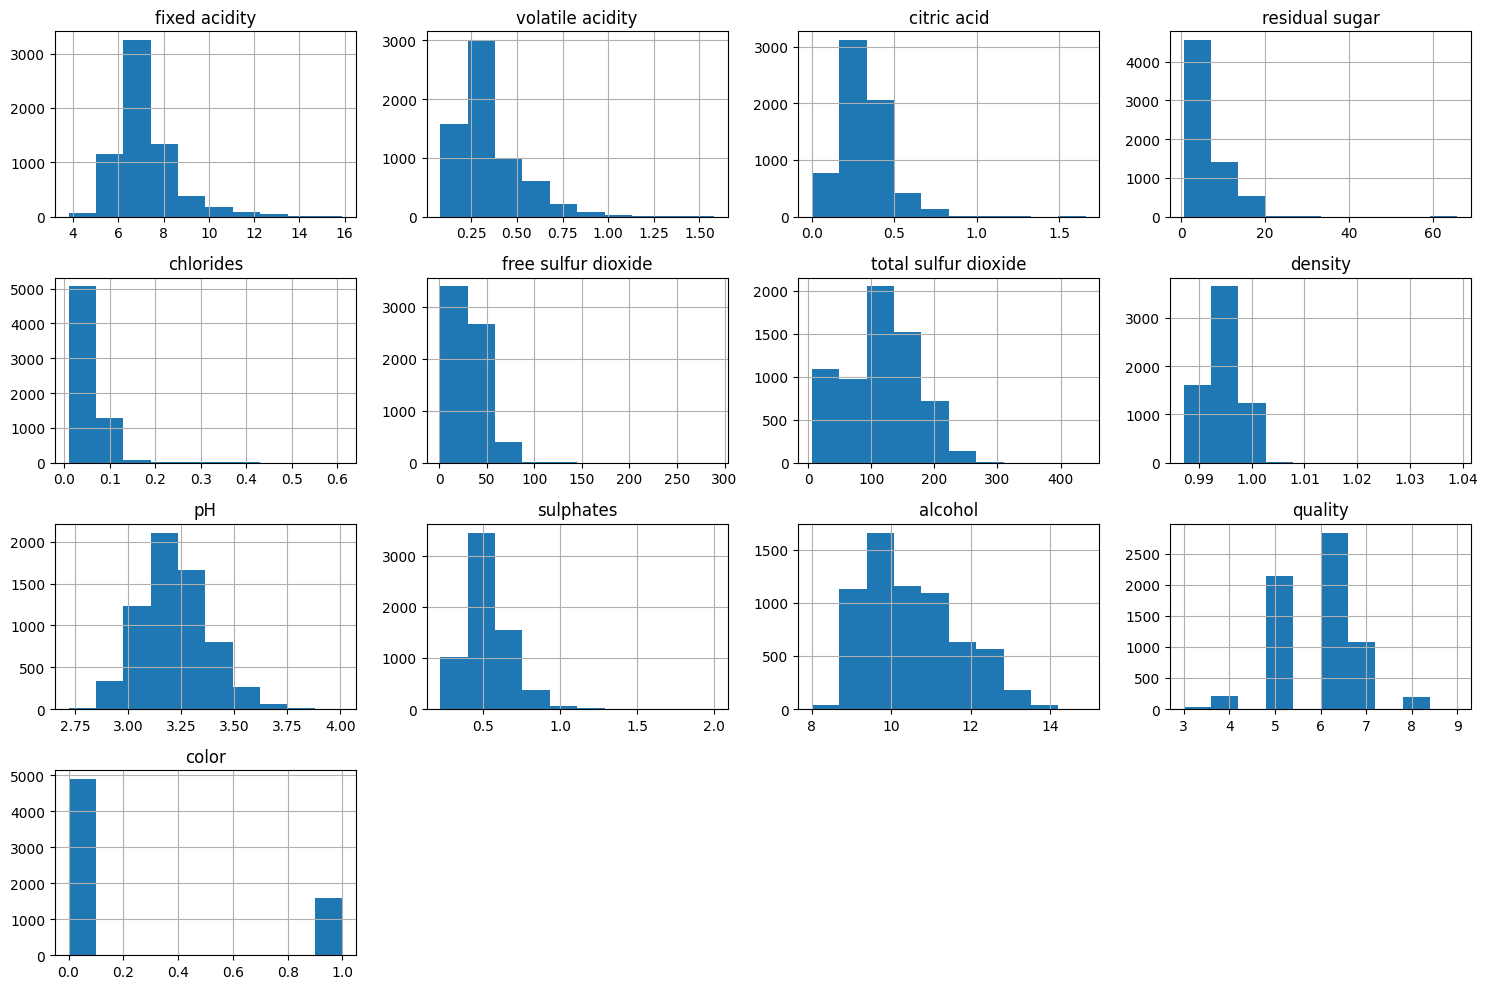

In [ ]:
# Histogram (각 컬럼별로 subplot 생성)
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

## Decision Tree 기본

In [ ]:
data['quality_group'] = pd.qcut(data['quality'], 3, labels=[0, 1, 2])
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color,quality_group
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1.0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1.0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1.0,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0.0,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0.0,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0.0,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0.0,2


In [ ]:
# 데이터 분할
X = data.drop(['quality', 'quality_group'], axis=1)
y = data['quality_group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. 기본적인 DecisionTree 학습, 트리 시각화, 테스트 정확도
dt_basic = DecisionTreeClassifier()
dt_basic.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_basic = dt_basic.predict(X_test)
accuracy_basic = accuracy_score(y_test, y_pred_basic)

In [ ]:
print("기본 DecisionTree 테스트 정확도:", accuracy_basic)

기본 DecisionTree 테스트 정확도: 0.6453846153846153


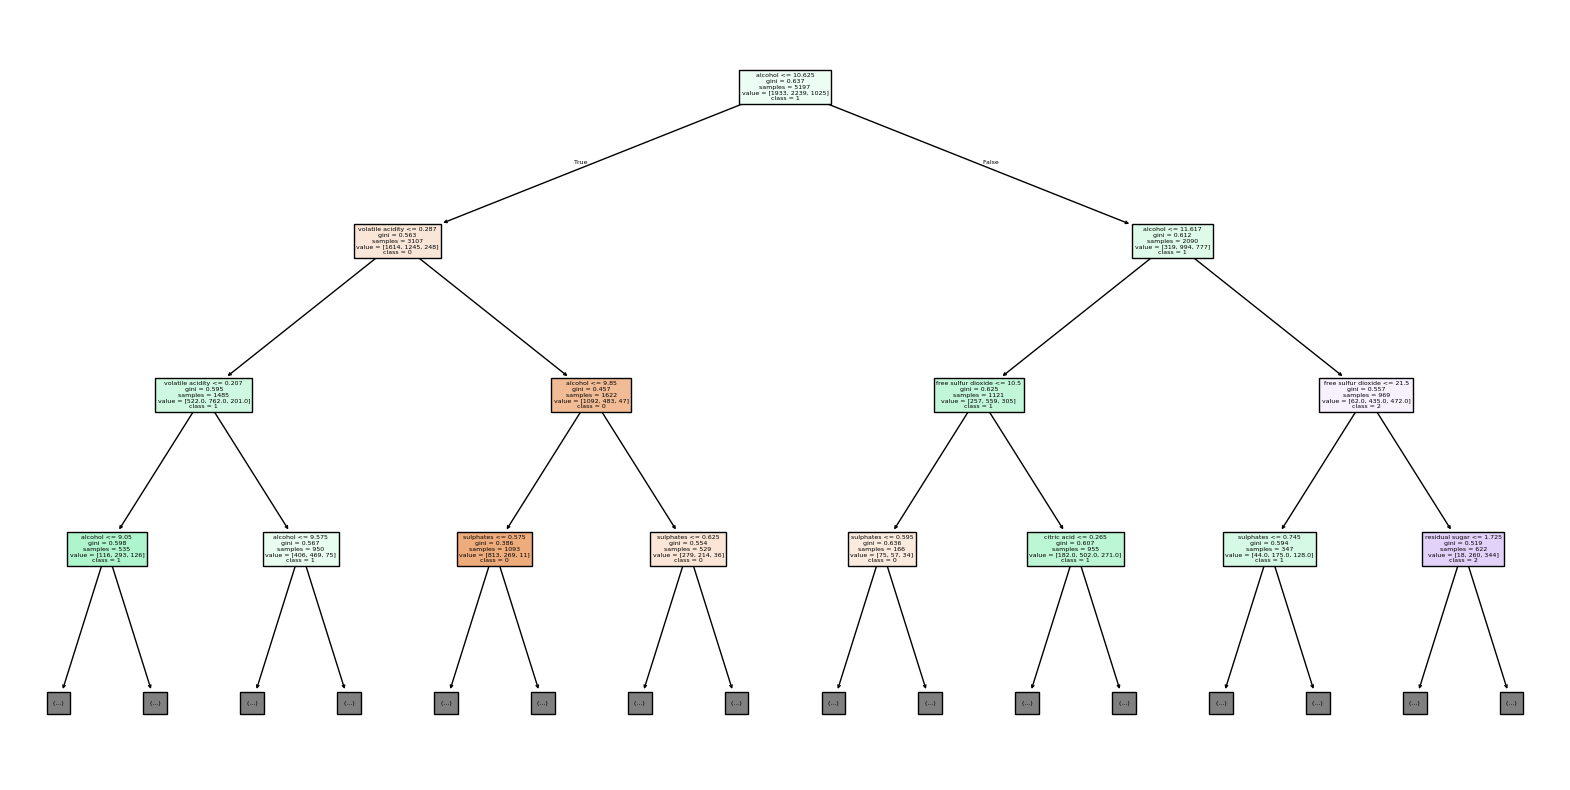

In [ ]:
plt.figure(figsize=(20, 10)) # plot 크기 조절
plot_tree(dt_basic, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str), max_depth=3) # class_names 추가 및 max_depth 제한
plt.show()

## 노드 수에 따른 정확도 변화

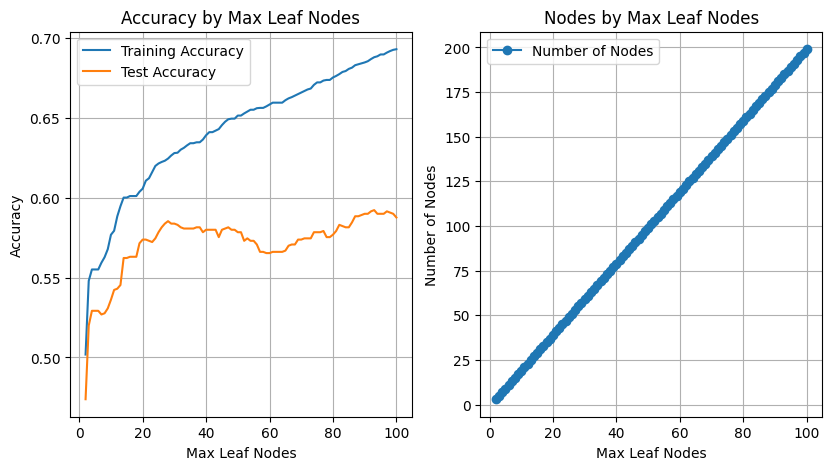

In [ ]:
# 2. max_leaf_nodes 조절에 따른 정확도 및 노드 수 변화
train_accuracies = []
test_accuracies = []
node_counts = []
leaf_nodes = range(2, 101, 1)

for leaf in leaf_nodes:
    dt = DecisionTreeClassifier(max_leaf_nodes=leaf, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)
    train_accuracies.append(accuracy_score(y_train, y_pred_train))
    test_accuracies.append(accuracy_score(y_test, y_pred_test))
    node_counts.append(dt.tree_.node_count)

# 그래프 그리기
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(leaf_nodes, train_accuracies, label='Training Accuracy')
plt.plot(leaf_nodes, test_accuracies, label='Test Accuracy')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Accuracy')
plt.title('Accuracy by Max Leaf Nodes')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(leaf_nodes, node_counts, marker='o', linestyle='-', label='Number of Nodes')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Number of Nodes')
plt.title('Nodes by Max Leaf Nodes')
plt.legend()
plt.grid(True)

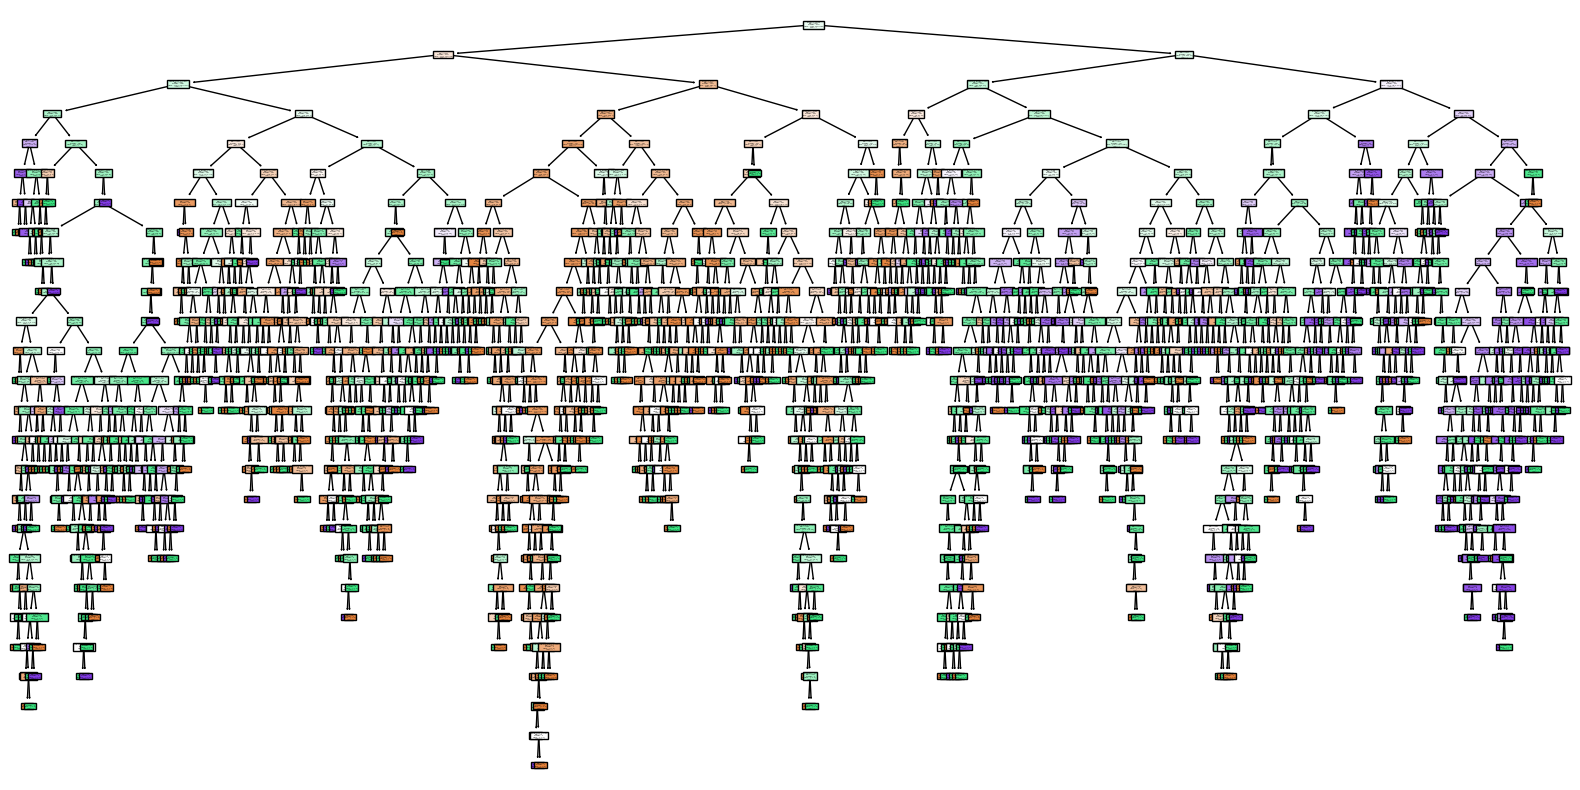

In [ ]:
plt.figure(figsize=(20, 10)) # plot 크기 조절
plot_tree(dt_basic, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str))
plt.show()

## 하이퍼 파라미터

In [ ]:
# 데이터 분할
X = data.drop(['color', 'quality_group'], axis=1)
y = data['color']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
dt_basic = DecisionTreeClassifier()
dt_basic.fit(X_train, y_train)

y_pred_basic = dt_basic.predict(X_test)
accuracy_basic = accuracy_score(y_test, y_pred_basic)

print("기본 DecisionTree 테스트 정확도:", accuracy_basic)

기본 DecisionTree 테스트 정확도: 0.9792307692307692


최적 하이퍼 파라미터: {'criterion': 'entropy', 'max_depth': 17, 'max_leaf_nodes': 85, 'min_samples_leaf': 1, 'min_samples_split': 4, 'splitter': 'random'}
최적 하이퍼 파라미터의 정확도: 0.9865314281483677
최적 모델의 테스트 정확도: 0.98


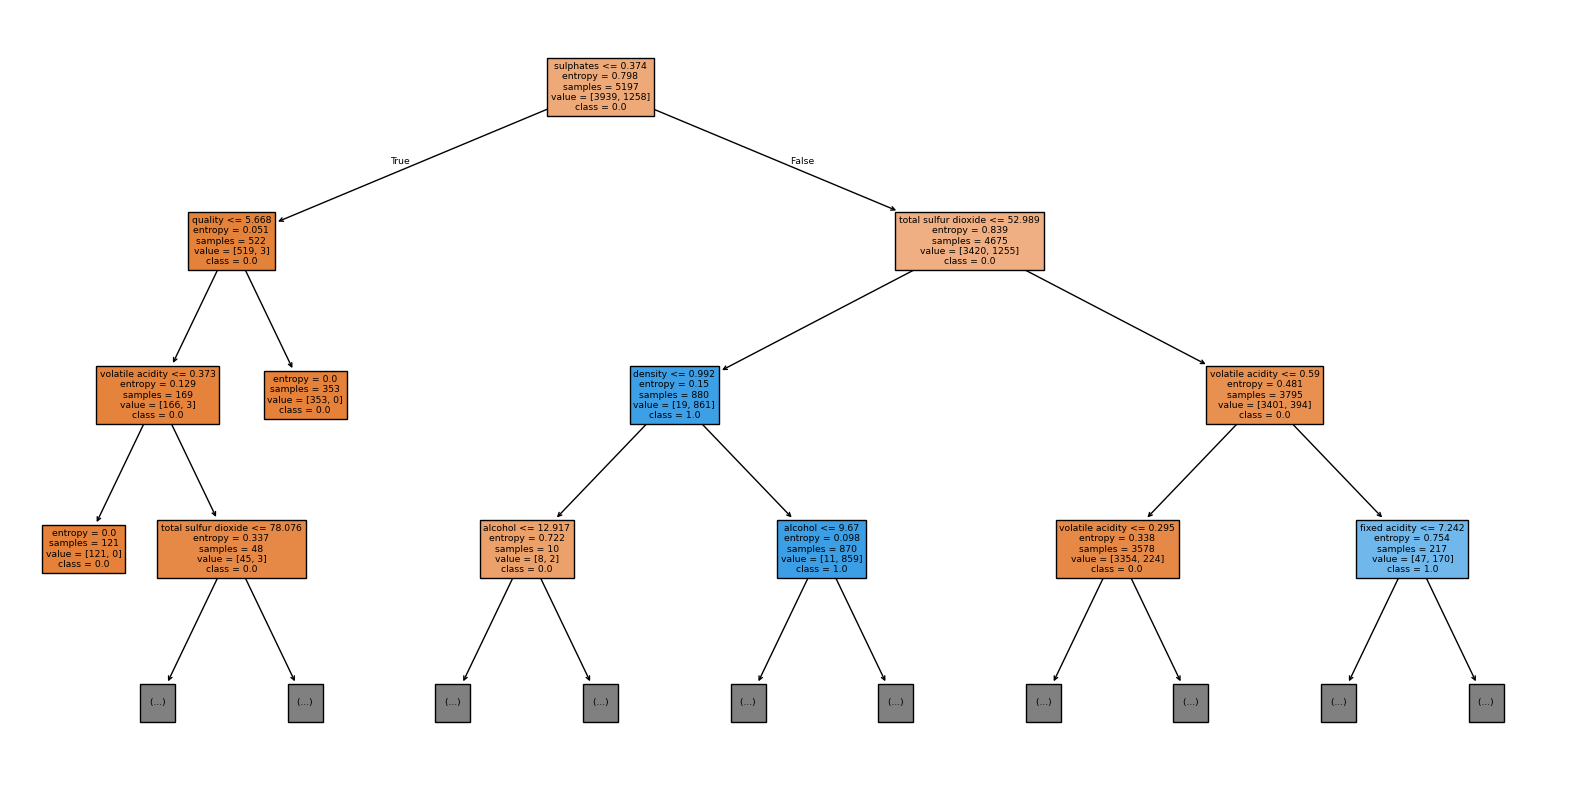

In [ ]:
# 3. GridSearchCV로 최적의 하이퍼 파라미터 서치 후 트리 시각화, 정확도 확인
param_grid = {
    'max_depth': range(3, 21, 2),
    'min_samples_split': range(2, 21, 2),
    'min_samples_leaf': range(1, 6, 2),
    'max_leaf_nodes': range(10, 101, 5),
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("최적 하이퍼 파라미터:", grid_search.best_params_)
print("최적 하이퍼 파라미터의 정확도:", grid_search.best_score_)

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print("최적 모델의 테스트 정확도:", accuracy_best)

plt.figure(figsize=(20, 10))
plot_tree(best_dt, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str), max_depth=3)
plt.show()

# 과제

자동차 평가 데이터 베이스를 이용한 Decision Tree 실습

Bohanec, M. (1988). Car Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JP48.

In [24]:
pip install ucimlrepo

In [25]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

In [26]:
X

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


In [27]:
y

,class
0,unacc
1,unacc
2,unacc
3,unacc
4,unacc
...,...
1723,good
1724,vgood
1725,unacc
1726,good


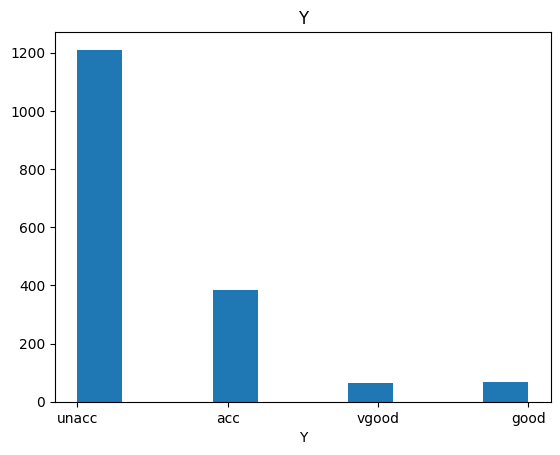

In [28]:
import matplotlib.pyplot as plt

plt.hist(y)
plt.xlabel('Y')
plt.title('Y')
plt.show()

## 데이터셋 컬럼 설명

*   `buying`: 구매 가격
*   `maint`: 유지 보수 비용
*   `doors`: 문의 개수
*   `persons`: 탑승 가능 인원 수
*   `lug_boot`: 수납 공간 크기
*   `safety`: 안전 등급

## 1. Decision Tree 기본으로 성능 확인

In [29]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
dtypes: object(6)
memory usage: 81.1+ KB


In [7]:
print(X["buying"].value_counts())
print(X["maint"].value_counts())
print(X["doors"].value_counts())
print(X["persons"].value_counts())
print(X["lug_boot"].value_counts())
print(X["safety"].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64


In [30]:
# CAtboost를 위한split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# TODO: 데이터를 트레인 데이터와 테스트 데이터로 나눈 뒤 Decision Tree에 학습시켜서 테스트 데이터 정확도가 얼마나 나오는지 확인
# Tip: X값이 범주형일 경우 수치형으로 인코딩을 해줘야 합니다.

from sklearn.preprocessing import LabelEncoder
# Label Encoding 적용
encoder = LabelEncoder()
for col in X.columns:
    X[col] = encoder.fit_transform(X[col])

<ipython-input-8-b1bcfa88d293>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
<ipython-input-8-b1bcfa88d293>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
<ipython-input-8-b1bcfa88d293>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=40)


In [13]:
DT = DecisionTreeClassifier()
DT.fit(train_X, train_y)

pred_y = DT.predict(test_X)
accuracy = accuracy_score(test_y, pred_y)

print("테스트 데이터 정확도:", accuracy)

테스트 데이터 정확도: 0.976878612716763


## 2. 최적의 하이퍼파라미터 성능 내보기

최적 하이퍼 파라미터: {'criterion': 'entropy', 'max_depth': 13, 'max_leaf_nodes': 85, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
최적 하이퍼 파라미터의 정확도: 0.9775754721917019
테스트 데이터 정확도: 0.9826589595375722


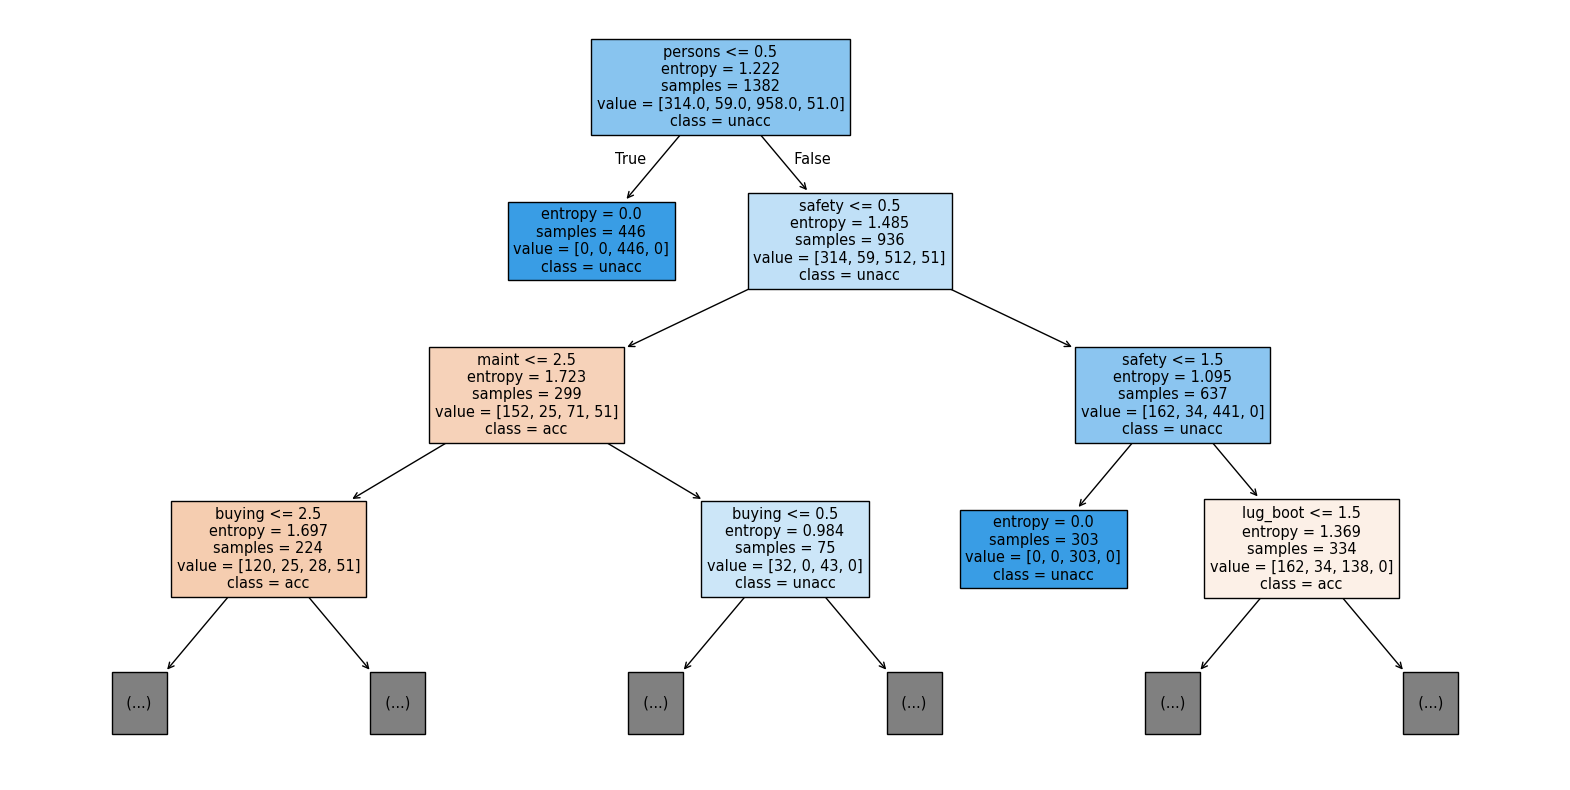

In [ ]:
# TODO: 데이터에 알맞는 Decision Tree의 최적의 하이퍼 파라미터를 GridSearch를 통해 찾아보고 테스트 데이터 정확도 출력
param_grids = {
    'max_depth': range(3, 21, 2),
    'min_samples_split': range(2, 21, 2),
    'min_samples_leaf': range(1, 6, 2),
    'max_leaf_nodes': range(10,101,5),
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

Grid_DT=DecisionTreeClassifier(random_state=40)
grid_search = GridSearchCV(Grid_DT, param_grids, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(train_X, train_y)

best_DT = grid_search.best_estimator_
pred_y_best = best_DT.predict(test_X)
best_accuracy = accuracy_score(test_y,pred_y_best)

print("최적 하이퍼 파라미터:", grid_search.best_params_)
print("최적 하이퍼 파라미터의 정확도:", grid_search.best_score_)
print("테스트 데이터 정확도:", best_accuracy)

plt.figure(figsize=(20, 10))
plot_tree(best_DT, filled=True, feature_names=X.columns, class_names=np.unique(y).astype(str), max_depth=3)
plt.show()

## 3. 다른 앙상블 모델 사용해보기

In [ ]:
# TODO: Decision Tree가 아닌 다른 앙상블 모델에 훈련 데이터를 학습시켜서 테스트 데이터 정확도 확인

### **Boosting( LightGBM, XGBoost, Adaboost )**

In [16]:
train_y.info()
le=LabelEncoder()
train_y2=le.fit_transform(train_y)
test_y2=le.fit_transform(test_y)

<class 'pandas.core.frame.DataFrame'>
Index: 1382 entries, 1264 to 1350
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   1382 non-null   object
dtypes: object(1)
memory usage: 21.6+ KB


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21
[LightGBM] [Info] Number of data points in the train set: 1382, number of used features: 6
[LightGBM] [Info] Start training from score -1.481894
[LightGBM] [Info] Start training from score -3.153750
[LightGBM] [Info] Start training from score -0.366439
[LightGBM] [Info] Start training from score -3.299461
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


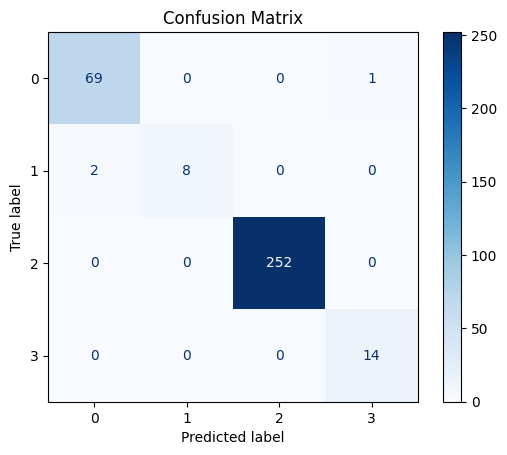

In [19]:
import lightgbm as lgb

# LightGBM 데이터 형식으로 변환
train_data = lgb.Dataset(train_X, label=train_y2)

# 하이퍼파라미터 설정
params = {
    'objective': 'multiclass',  # 다중 클래스 분류
    'num_class': 4,             # 클래스 개수
    'learning_rate': 0.05,
    'num_leaves': 31,
    'metric': 'multi_logloss'   # 다중 클래스 로그손실
}

# 모델 학습
lgb_model = lgb.train(params, train_data, num_boost_round=100)

# 예측 (클래스 확률값)
y_pred_prob = lgb_model.predict(test_X)

# 클래스 예측 (가장 큰 확률의 클래스 선택)
import numpy as np
y_pred = np.argmax(y_pred_prob, axis=1)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 혼동 행렬 생성
cm = confusion_matrix(test_y2, y_pred)

# 혼동 행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])  # 클래스 라벨 설정
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Accuracy (LightGBM): 0.9913

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        70
           1       1.00      0.80      0.89        10
           2       1.00      1.00      1.00       252
           3       0.93      1.00      0.97        14

    accuracy                           0.99       346
   macro avg       0.98      0.95      0.96       346
weighted avg       0.99      0.99      0.99       346



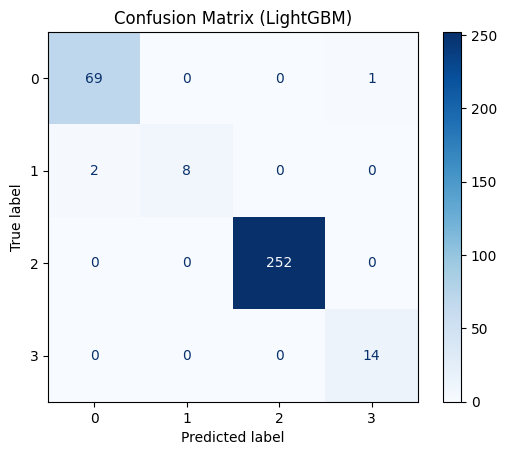

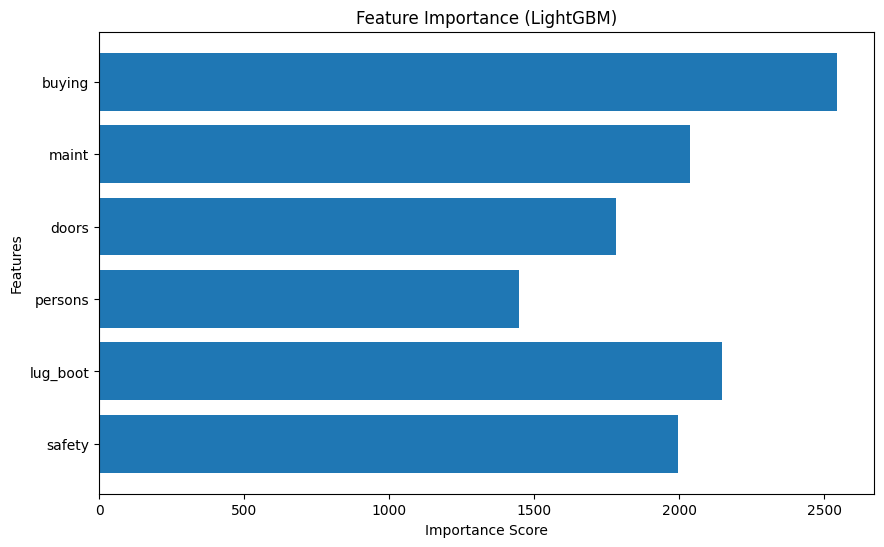

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# 정확도 출력
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (LightGBM): {accuracy:.4f}")

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(test_y2, y_pred))

# 혼동 행렬 시각화
cm = confusion_matrix(test_y2, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (LightGBM)")
plt.show()

# Feature Importance 시각화
importance = lgb_model.feature_importance(importance_type='split')  # split 기준 중요도
features = train_X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importance)
plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

In [22]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# XGBoost 데이터 형식으로 변환
train_data = xgb.DMatrix(train_X, label=train_y2)
test_data = xgb.DMatrix(test_X)

# 하이퍼파라미터 설정
params = {
    'objective': 'multi:softprob',  # 다중 클래스 분류
    'num_class': 4,                # 클래스 개수
    'learning_rate': 0.05,
    'max_depth': 6,
    'eval_metric': 'mlogloss'      # 다중 클래스 로그손실
}

# 모델 학습
xgb_model = xgb.train(params, train_data, num_boost_round=100)

# 예측 (클래스 확률값)
y_pred_prob = xgb_model.predict(test_data)

# 클래스 예측 (가장 큰 확률의 클래스 선택)
y_pred = np.argmax(y_pred_prob, axis=1)

Accuracy (XGBoost): 0.9827

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        70
           1       1.00      0.70      0.82        10
           2       1.00      0.99      0.99       252
           3       0.93      1.00      0.97        14

    accuracy                           0.98       346
   macro avg       0.97      0.92      0.94       346
weighted avg       0.98      0.98      0.98       346



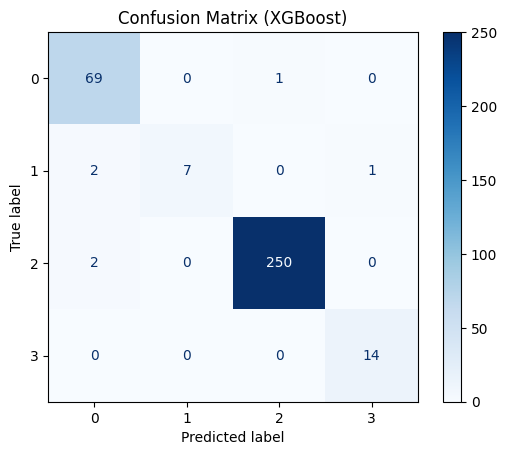

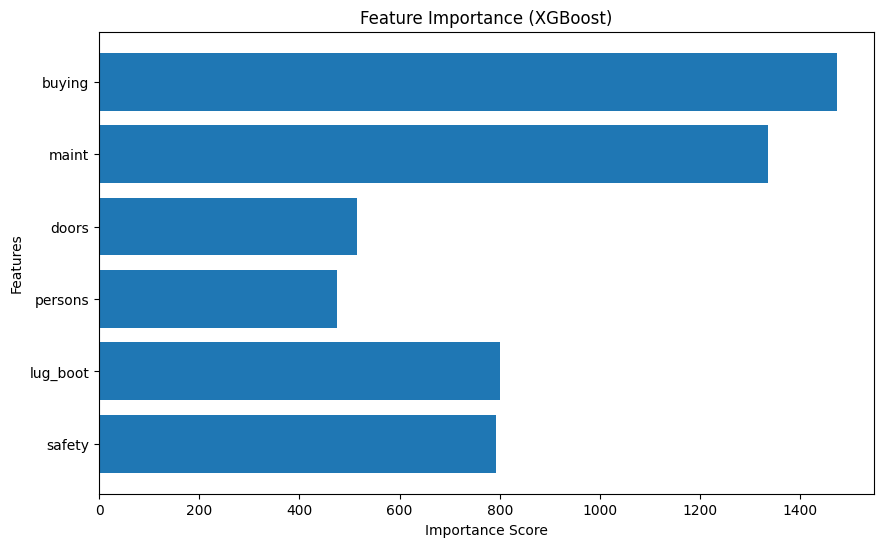

In [23]:
# 정확도 출력
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (XGBoost): {accuracy:.4f}")

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(test_y2, y_pred))

# 혼동 행렬 시각화
cm = confusion_matrix(test_y2, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (XGBoost)")
plt.show()

# Feature Importance 시각화
importance = xgb_model.get_score(importance_type='weight')  # weight 기준 중요도
features = list(importance.keys())
values = list(importance.values())

plt.figure(figsize=(10, 6))
plt.barh(features, values)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

Accuracy (AdaBoosting): 0.9769

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        70
           1       0.78      0.70      0.74        10
           2       1.00      1.00      1.00       252
           3       0.93      1.00      0.97        14

    accuracy                           0.98       346
   macro avg       0.91      0.91      0.91       346
weighted avg       0.98      0.98      0.98       346



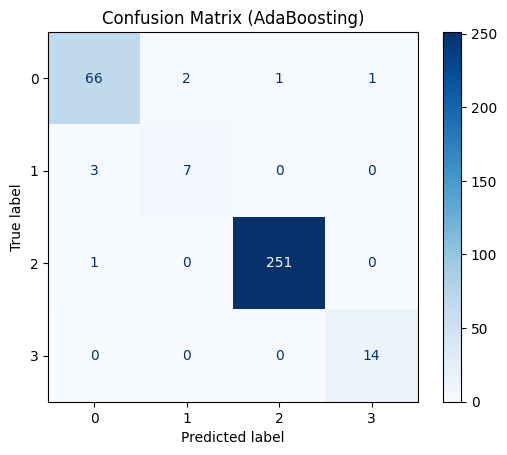

In [47]:
from sklearn.ensemble import AdaBoostClassifier

# AdaBoostingClassifier Boosting 모델 생성

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42)
ada_model.fit(train_X, train_y2)

# 예측
y_pred = ada_model.predict(test_X)

accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (AdaBoosting): {accuracy:.4f}")

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(test_y2, y_pred))

cm = confusion_matrix(test_y2, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ada_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (AdaBoosting)")
plt.show()

### **Bagging**

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [50, 100, 200],  # 트리 개수
    'max_depth': [None, 10, 20, 30],  # 최대 깊이
    'min_samples_split': [2, 5, 10],  # 노드 분할에 필요한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],    # 리프 노드의 최소 샘플 수
    'bootstrap': [True, False]        # 부트스트래핑 사용 여부
}

# Random Forest 모델 생성
rf_model = RandomForestClassifier(random_state=40)

# GridSearchCV 생성
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='accuracy',    # 평가 기준 (필요에 따라 변경 가능)
    cv=5,                  # 교차 검증 폴드 수
    verbose=2,             # 출력 레벨 (1이나 2로 설정하면 진행 상황 표시)
    n_jobs=-1              # 병렬 처리 (-1은 모든 CPU 코어 사용)
)

# 그리드 서치 실행
grid_search.fit(train_X, train_y)

# 최적 하이퍼파라미터와 최고 점수 출력
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# 최적 모델로 예측
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(test_X)

# 정확도 계산
accuracy = accuracy_score(test_y, y_pred)
print("Test Accuracy:", accuracy)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best Accuracy: 0.9717809867629361
Test Accuracy: 0.9797687861271677


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [39]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Bagging Classifier 생성
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    random_state=42
)
bagging_model.fit(train_X, train_y2)

# 예측
y_pred = bagging_model.predict(test_X)

Accuracy (Bagging Classifier): 0.9769

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        70
           1       0.75      0.90      0.82        10
           2       0.99      0.99      0.99       252
           3       0.93      1.00      0.97        14

    accuracy                           0.98       346
   macro avg       0.91      0.96      0.93       346
weighted avg       0.98      0.98      0.98       346



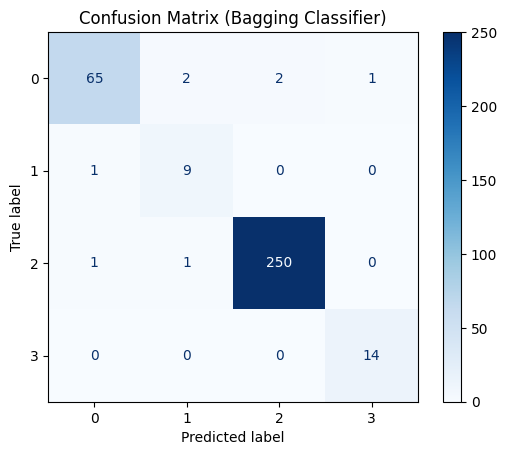

In [40]:
# 정확도 출력
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (Bagging Classifier): {accuracy:.4f}")

# Classification Report 출력
print("\nClassification Report:")
print(classification_report(test_y2, y_pred))

# 혼동 행렬 시각화
cm = confusion_matrix(test_y2, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bagging_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Bagging Classifier)")
plt.show()

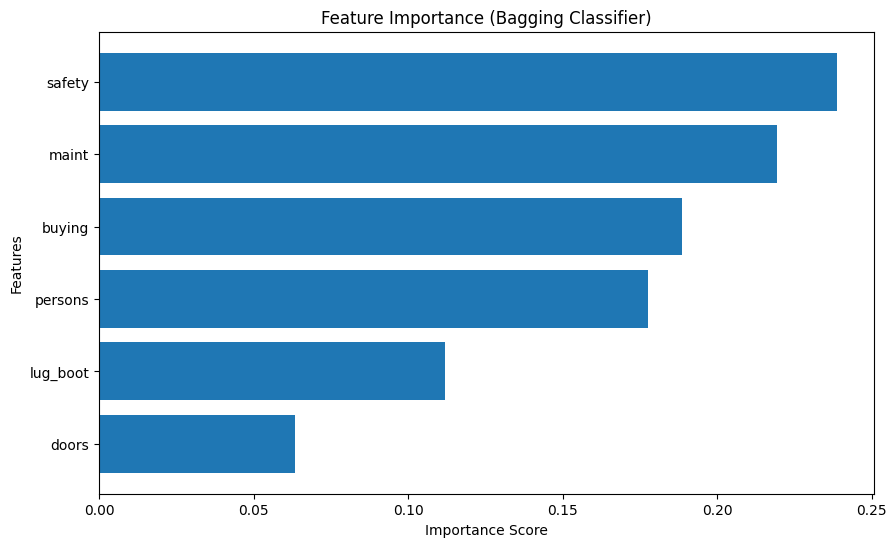

In [ ]:
# Feature Importance 계산
import pandas as pd

# Bagging을 구성하는 트리들의 Feature Importance를 평균 계산
feature_importances = np.mean(
    [tree.feature_importances_ for tree in bagging_model.estimators_], axis=0
)

# Feature Importance 시각화
features = train_X.columns
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importance (Bagging Classifier)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()


### **Voting**

In [45]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier  # 수정된 부분
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

# Voting Classifier 생성
Voting_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('lgb', lgb.LGBMClassifier(objective='multiclass', num_class=4, random_state=42)),
        ('cart', DecisionTreeClassifier(max_depth=None, random_state=42)),
        ('ada', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=50, random_state=42)),
        ('lr', LogisticRegression(random_state=42))
    ],
    voting='soft'
)

# 모델 학습
Voting_model.fit(train_X, train_y2)

# 예측
y_pred = Voting_model.predict(test_X)

# 정확도 확인
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (Voting Classifier): {accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21
[LightGBM] [Info] Number of data points in the train set: 1382, number of used features: 6
[LightGBM] [Info] Start training from score -1.481894
[LightGBM] [Info] Start training from score -3.153750
[LightGBM] [Info] Start training from score -0.366439
[LightGBM] [Info] Start training from score -3.299461
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [46]:
# Voting Classifier 생성
Voting_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('lgb', lgb.LGBMClassifier(objective='multiclass', num_class=4, random_state=42)),
        ('cart', DecisionTreeClassifier(max_depth=None, random_state=42)),  # 수정된 부분
        ('ada', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=50, random_state=42)),
        ('lr', LogisticRegression(random_state=42))
    ],
    voting='hard'
)

# 모델 학습
Voting_model.fit(train_X, train_y2)

# 예측
y_pred = Voting_model.predict(test_X)

# 정확도 확인
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (Voting Classifier): {accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21
[LightGBM] [Info] Number of data points in the train set: 1382, number of used features: 6
[LightGBM] [Info] Start training from score -1.481894
[LightGBM] [Info] Start training from score -3.153750
[LightGBM] [Info] Start training from score -0.366439
[LightGBM] [Info] Start training from score -3.299461
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

### **Stacking**

In [36]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 개별 모델 정의
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('lgb', lgb.LGBMClassifier(objective='multiclass', num_class=4, random_state=42)),
]

# 스태킹 모델 생성
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

# 모델 학습 및 예측
stacking_model.fit(train_X, train_y2)
y_pred = stacking_model.predict(test_X)

# 성능 평가
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (Simple Stacking): {accuracy:.4f}")

Accuracy (Simple Stacking): 0.9971


Accuracy (Meta Model - Simple Stacking): 0.9942

Classification Report (Meta Model):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        70
           1       1.00      0.80      0.89        10
           2       1.00      1.00      1.00       252
           3       1.00      1.00      1.00        14

    accuracy                           0.99       346
   macro avg       0.99      0.95      0.97       346
weighted avg       0.99      0.99      0.99       346



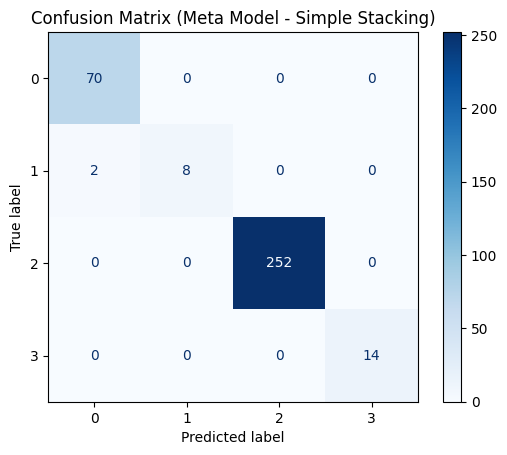

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 스태킹 모델 학습
stacking_model.fit(train_X, train_y2)

# 메타 모델 입력 데이터 추출
meta_X_train = stacking_model.transform(train_X)  # 메타 모델 학습용 데이터
meta_X_test = stacking_model.transform(test_X)    # 메타 모델 테스트용 데이터

# 메타 모델 정의 및 학습 (Logistic Regression)
meta_model = LogisticRegression(random_state=42)
meta_model.fit(meta_X_train, train_y2)

# 메타 모델로 예측
meta_y_pred = meta_model.predict(meta_X_test)

# 메타 모델 성능 평가
meta_accuracy = accuracy_score(test_y2, meta_y_pred)
print(f"Accuracy (Meta Model - Simple Stacking): {meta_accuracy:.4f}")

print("\nClassification Report (Meta Model):")
print(classification_report(test_y2, meta_y_pred))

# 혼동 행렬 시각화
cm = confusion_matrix(test_y2, meta_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(train_y2))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Meta Model - Simple Stacking)")
plt.show()


In [22]:
from sklearn.ensemble import StackingClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 기본 학습기 설정
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),  # SVM은 확률 예측 필요
    ('bagging', BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42)),
]

# 스태킹 모델 생성
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=GradientBoostingClassifier(n_estimators=100, random_state=42),
    n_jobs=-1
)

# 모델 학습 및 예측
stacking_model.fit(train_X, train_y2)
y_pred = stacking_model.predict(test_X)

# 성능 평가
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (Complex Stacking): {accuracy:.4f}")


Accuracy (Complex Stacking): 0.9827


Accuracy (Meta Model - Complex Stacking): 0.9827

Classification Report (Meta Model):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        70
           1       0.78      0.70      0.74        10
           2       1.00      1.00      1.00       252
           3       1.00      1.00      1.00        14

    accuracy                           0.98       346
   macro avg       0.93      0.91      0.92       346
weighted avg       0.98      0.98      0.98       346



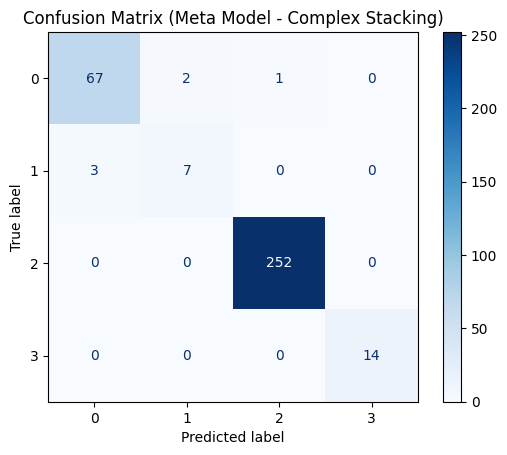

In [23]:
# 스태킹 모델 학습
stacking_model.fit(train_X, train_y2)

# 메타 모델 입력 데이터 추출
meta_X_train = stacking_model.transform(train_X)
meta_X_test = stacking_model.transform(test_X)

# 메타 모델 정의 및 학습 (Gradient Boosting)
from sklearn.ensemble import GradientBoostingClassifier
meta_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
meta_model.fit(meta_X_train, train_y2)

# 메타 모델로 예측
meta_y_pred = meta_model.predict(meta_X_test)

# 메타 모델 성능 평가
meta_accuracy = accuracy_score(test_y2, meta_y_pred)
print(f"Accuracy (Meta Model - Complex Stacking): {meta_accuracy:.4f}")

print("\nClassification Report (Meta Model):")
print(classification_report(test_y2, meta_y_pred))

# 혼동 행렬 시각화
cm = confusion_matrix(test_y2, meta_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(train_y2))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Meta Model - Complex Stacking)")
plt.show()


In [24]:
from sklearn.neural_network import MLPClassifier

# 기본 학습기 설정
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=300, random_state=42)),
]

# 스태킹 모델 생성
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

# 모델 학습 및 예측
stacking_model.fit(train_X, train_y2)
y_pred = stacking_model.predict(test_X)

# 성능 평가
accuracy = accuracy_score(test_y2, y_pred)
print(f"Accuracy (Neural Network Stacking): {accuracy:.4f}")


Accuracy (Neural Network Stacking): 0.9971


Accuracy (Meta Model - Neural Network Stacking): 0.9913

Classification Report (Meta Model):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        70
           1       1.00      0.80      0.89        10
           2       1.00      1.00      1.00       252
           3       0.93      1.00      0.97        14

    accuracy                           0.99       346
   macro avg       0.98      0.95      0.96       346
weighted avg       0.99      0.99      0.99       346



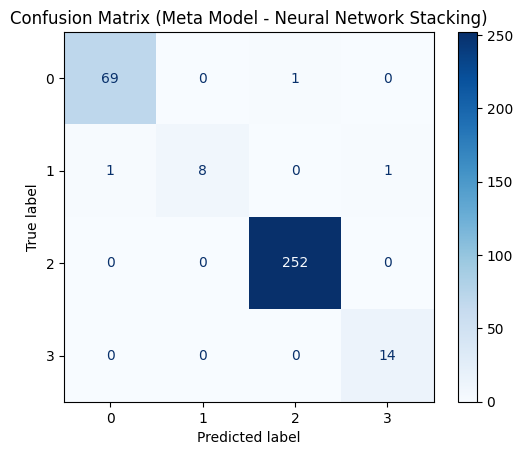

In [25]:
from sklearn.neural_network import MLPClassifier

# 스태킹 모델 학습
stacking_model.fit(train_X, train_y2)

# 메타 모델 입력 데이터 추출
meta_X_train = stacking_model.transform(train_X)
meta_X_test = stacking_model.transform(test_X)

# 메타 모델 정의 및 학습 (Neural Network - MLPClassifier)
meta_model = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=300, random_state=42)
meta_model.fit(meta_X_train, train_y2)

# 메타 모델로 예측
meta_y_pred = meta_model.predict(meta_X_test)

# 메타 모델 성능 평가
meta_accuracy = accuracy_score(test_y2, meta_y_pred)
print(f"Accuracy (Meta Model - Neural Network Stacking): {meta_accuracy:.4f}")

print("\nClassification Report (Meta Model):")
print(classification_report(test_y2, meta_y_pred))

# 혼동 행렬 시각화
cm = confusion_matrix(test_y2, meta_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(train_y2))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Meta Model - Neural Network Stacking)")
plt.show()

## 최종 분석

1. 선택한 앙상블 모델에 대한 간단한 설명
2. 3가지 실행 정확도 결과에 대한 비교 분석

**4가지 Ensemble 학습 결과**

1.   Boosting:단일 모델을 순차적으로 활용한다는 특징을 가지고 있음

  *   Adaboosting: 이전학습기의 오류를 보완하여 약한 학습기를 결합하는 방식을 사용함
  *   LightGBM: GBM 기반 알고리즘으로, 예측에 실패한 부분에 가중치를 더하면서 오차를 보완하는 식으로 순차적으로 트리를 만드는 과정인데, 리프 중심 트리분할을 써서 기존 균형트리분할에 비해 더빠른 예측 수행시간이 장점임
  *   XGBoost: Gradient Boosting과 Regularization등을 적용하여 성능을 좀 더 보완하는 방식임
  *   CatBoost:대칭트리 구조를 사용하고 카테고리형 변수를 최적화함.(참고용으로 search함)



*   LGBM:99.12%/ XGBoost:98.27%/ AdaBoost: 97.69%/
*   LGBM과 XGBoost의 공통적 feature importance는 Buying변수였고, 더 좋은 성능을 나타낸 LGBM의 두번째 중요 Feature가 lug_boot였으므로 두가지변수가 중요하다고 보여짐




---



2.   Bagging: 기존 학습데이터로부터 랜덤하게 복원추출하여 동일한 사이즈의 데이터셋을 여러개 만들어 앙상블을 구성하는 모델임

  *   RandomForest: Bagging 기반이지만 추가적 랜덤성(feature중 일부만 선택하는 방식)
  *   Bagging Decision Tree: 부트스트랩 샘플을 모든 feature(동일하게) 이용하여 여러개를 조합하는 방식


*   RandomForest 97.97% test accuracy이고, 오히려 Train에서는 이보다 작은 97.1%대여서, 더 좋은 특성으로 학습될 수 있을 여지가 있다. 과소적합 느낌이다.
*   Bagging DT역시 97.69%로 다른 모델에 비해 좀 낮은 정확도를 보이고 있다.


---




3.   Voting:  Soft voting , Hard voting을 이용하되, 여러 모델을 섞어서 사용하여 투표하는 방식

  *   Soft: 각 모델의 예측확률을 평균을 내거나, 가중평균을 사용하여 최종 예측을 결정함
  *   Hard: Majority voting방식으로 다수결에 따름



*   Hard voting의 성능이미세하게 좋게 나타남(98.55%)
*   이유는, 선택된 모델들이 유사하게 틀리는 부분이 있을 텐데, 유의미하게 성능 차이가 여기서 많이나서 soft voting을 할경우 성능이 좀 낮아질 수 있다고 생각함


---



4.   Stacking: 여러가지 모델을 사용하여 학습을 진행하고 이를 바탕으로 메타 모델을 만들어 성능을 최적화하는 형태임

  *   RandomForest,LGBM,GBM 으로 학습
  *   BaggingClassifier, SVM, RF, DT로 학습
  *   RF, MLP,GBM으로 학습


*   가장 우수한 성능은(not using MLP)는 RF,LGBM, GBM으로 학습한 SImple한 모델이었음(99.42%)
*   Linear classifer인 SVM을 넣었을 경우 train에 더 과적합된 것 같음
*   MLP를 넣은 경우, 99.71%까지 오름, 모델의 복잡성을 통해 더 미세한 특징을 학습했다고 볼 수 있음





---

***결론***


*   Stacking>Boosting>Voting>Bagging 순으로 성능이 좋았음
*   다양한 모델을 쓸 경우, 적절한 조화는 데이터 내 내재된 특징을 잘참조할 수 있을 것이라는 insight를 얻음
*   이후 모든 과정에서 GRID Search과정을 넣을 경우 더 높은 정확도를 갖출 수 있을 것이고, Accuracy측면 뿐만 아니라, 다른 지표 (f1-score)등을 참조하여 학습하면 더 좋을 것 같음

